# PAM Feature EDA

This notebook is for deciding which PAMAP2 feature groups are worth keeping before regenerating the processed subject files.

It focuses on:
- subject coverage and class coverage
- missingness before interpolation
- per-feature variance
- subject shift by feature group
- simple linear baselines for feature-group comparison

Suggested workflow:
1. Run the setup cells.
2. Inspect subject/class coverage first.
3. Inspect missingness and low-variance features.
4. Compare feature groups like `full`, `no_orientation`, `no_orientation_no_temp`, `acc_gyro`, and `acc_gyro_mag`.
5. Decide what to remove, then regenerate PAM `.pkl` files.


In [1]:
from pathlib import Path
import json
import numpy as np

try:
    import pandas as pd
except ImportError:
    raise ImportError('This notebook expects pandas in the notebook environment.')

try:
    import matplotlib.pyplot as plt
except ImportError:
    raise ImportError('This notebook expects matplotlib in the notebook environment.')

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    sns = None

try:
    from sklearn.decomposition import PCA
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
except ImportError:
    raise ImportError('This notebook expects scikit-learn in the notebook environment.')


In [2]:
DATA_DIR = Path('/home/pham156/MoE/FuseMoE_poly/data/PAM_Protocol')
META_PATH = Path('/home/pham156/MoE/FuseMoE_poly/data/PAM/subject_metadata.json')
SUBJECT_IDS = list(range(1, 10))

if META_PATH.exists():
    metadata = json.loads(META_PATH.read_text())
    metadata
else:
    metadata = None
    print('subject_metadata.json not found; raw-file EDA still works.')


In [3]:
def get_pamap_column_names():
    columns = ['timestamp', 'activity_id', 'heart_rate']

    for location in ['hand', 'chest', 'ankle']:
        columns.append(f'temp_{location}')
        for sensor_type in ['acc16g', 'acc6g', 'gyro', 'mag']:
            for axis in ['x', 'y', 'z']:
                columns.append(f'{sensor_type}_{axis}_{location}')
        for q in ['1', '2', '3', '4']:
            columns.append(f'orient_{q}_{location}')
    return columns

COLS = get_pamap_column_names()
len(COLS), COLS[:10], COLS[-10:]


(54,
 ['timestamp',
  'activity_id',
  'heart_rate',
  'temp_hand',
  'acc16g_x_hand',
  'acc16g_y_hand',
  'acc16g_z_hand',
  'acc6g_x_hand',
  'acc6g_y_hand',
  'acc6g_z_hand'],
 ['gyro_x_ankle',
  'gyro_y_ankle',
  'gyro_z_ankle',
  'mag_x_ankle',
  'mag_y_ankle',
  'mag_z_ankle',
  'orient_1_ankle',
  'orient_2_ankle',
  'orient_3_ankle',
  'orient_4_ankle'])

In [4]:
def load_subject(subject_id):
    path = DATA_DIR / f'subject10{subject_id}.dat'
    return pd.read_csv(path, sep=r'\s+', header=None, names=COLS)

raw_subjects = {sid: load_subject(sid) for sid in SUBJECT_IDS}
{k: v.shape for k, v in raw_subjects.items()}


{1: (376417, 54),
 2: (447000, 54),
 3: (252833, 54),
 4: (329576, 54),
 5: (374783, 54),
 6: (361817, 54),
 7: (313599, 54),
 8: (408031, 54),
 9: (8477, 54)}

In [5]:
# Subject-level quick check
summary_rows = []
for sid, df in raw_subjects.items():
    nonzero = df[df['activity_id'] != 0].copy()
    acts = sorted(nonzero['activity_id'].dropna().astype(int).unique().tolist())
    summary_rows.append({
        'subject': sid,
        'rows_total': len(df),
        'rows_nonzero': len(nonzero),
        'num_nonzero_activities': len(acts),
        'activities': acts,
    })

subject_summary = pd.DataFrame(summary_rows)
subject_summary


,subject,rows_total,rows_nonzero,num_nonzero_activities,activities
0,1,376417,249957,12,"[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]"
1,2,447000,263349,12,"[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]"
2,3,252833,174338,8,"[1, 2, 3, 4, 12, 13, 16, 17]"
3,4,329576,231421,11,"[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17]"
4,5,374783,272442,12,"[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]"
5,6,361817,250096,12,"[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]"
6,7,313599,232776,11,"[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17]"
7,8,408031,262102,12,"[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]"
8,9,8477,6391,1,[24]


In [6]:
# If available, compare with processed-window metadata
if metadata is not None:
    proc_rows = []
    for sid in SUBJECT_IDS:
        proc = metadata['subjects'][str(sid)]
        proc_rows.append({
            'subject': sid,
            'windows': proc['total_windows'],
            'class_distribution': proc['class_distribution'],
        })
    processed_summary = pd.DataFrame(proc_rows)
    display(processed_summary[['subject', 'windows']])
else:
    print('No processed metadata found.')


,subject,windows
0,1,4998
1,2,5265
2,3,3485
3,4,4627
4,5,5447
5,6,5000
6,7,4654
7,8,5241
8,9,126


In [7]:
# Missingness before interpolation
missing_rows = []
for sid, df in raw_subjects.items():
    feat = df.drop(columns=['timestamp', 'activity_id'])
    miss = feat.isna().mean().sort_values(ascending=False)
    missing_rows.append(pd.DataFrame({
        'subject': sid,
        'feature': miss.index,
        'missing_ratio': miss.values,
    }))
missing_df = pd.concat(missing_rows, ignore_index=True)
missing_df.sort_values(['missing_ratio', 'subject'], ascending=[False, True]).head(20)


,subject,feature,missing_ratio
364,8,heart_rate,0.908882
52,2,heart_rate,0.908736
208,5,heart_rate,0.908686
260,6,heart_rate,0.908658
312,7,heart_rate,0.908654
104,3,heart_rate,0.908651
0,1,heart_rate,0.908641
156,4,heart_rate,0.908625
416,9,heart_rate,0.908458
157,4,temp_hand,0.006718


In [8]:
# Average missingness by feature
feature_missing = missing_df.groupby('feature', as_index=False)['missing_ratio'].mean()
feature_missing = feature_missing.sort_values('missing_ratio', ascending=False)
feature_missing.head(20)


,feature,missing_ratio
27,heart_rate,0.908666
2,acc16g_x_hand,0.004012
8,acc16g_z_hand,0.004012
11,acc6g_x_hand,0.004012
17,acc6g_z_hand,0.004012
14,acc6g_y_hand,0.004012
30,mag_x_hand,0.004012
33,mag_y_hand,0.004012
48,orient_4_hand,0.004012
51,temp_hand,0.004012


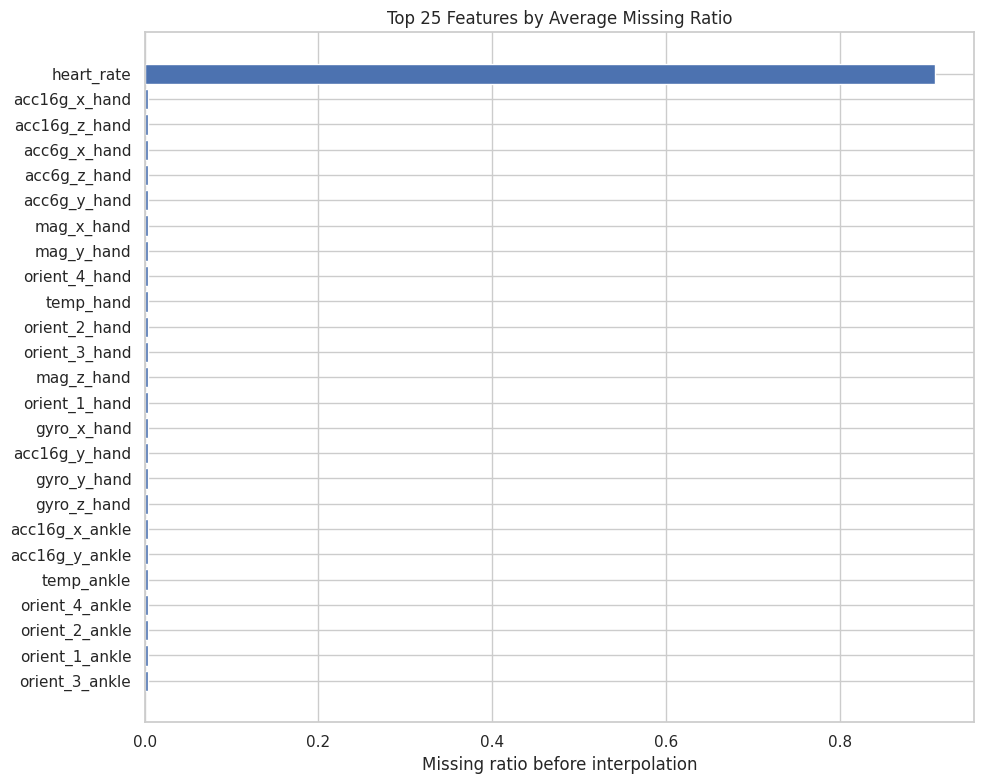

In [9]:
plt.figure(figsize=(10, 8))
plot_df = feature_missing.head(25).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['missing_ratio'])
plt.title('Top 25 Features by Average Missing Ratio')
plt.xlabel('Missing ratio before interpolation')
plt.tight_layout()
plt.show()


In [10]:
# Filter to protocol activities actually present in your local files
all_nonzero_activities = sorted({int(a) for df in raw_subjects.values() for a in df['activity_id'].dropna().unique() if int(a) != 0})
all_nonzero_activities


[1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]

In [11]:
# Feature grouping helpers
FEATURE_GROUPS = {
    'full': lambda cols: cols,
    'no_orientation': lambda cols: [c for c in cols if 'orient_' not in c],
    'no_orientation_no_temp': lambda cols: [c for c in cols if 'orient_' not in c and not c.startswith('temp_')],
    'acc_only': lambda cols: [c for c in cols if 'acc' in c or c == 'heart_rate'],
    'acc_gyro': lambda cols: [c for c in cols if ('acc' in c or 'gyro' in c or c == 'heart_rate')],
    'acc_gyro_mag': lambda cols: [c for c in cols if ('acc' in c or 'gyro' in c or 'mag_' in c or c == 'heart_rate')],
    'heart_rate_only': lambda cols: [c for c in cols if c == 'heart_rate'],
}

base_feature_cols = [c for c in COLS if c not in ['timestamp', 'activity_id']]
{key: len(fn(base_feature_cols)) for key, fn in FEATURE_GROUPS.items()}


{'full': 52,
 'no_orientation': 40,
 'no_orientation_no_temp': 37,
 'acc_only': 19,
 'acc_gyro': 28,
 'acc_gyro_mag': 37,
 'heart_rate_only': 1}

In [12]:
# Simple preprocessing similar to your current raw pipeline, but kept flat for EDA

def preprocess_df(df, feature_cols):
    out = df[['activity_id'] + feature_cols].copy()
    out = out.interpolate(method='linear', limit_direction='both')
    out = out.dropna()
    out = out[out['activity_id'] != 0].copy()
    out['activity_id'] = out['activity_id'].astype(int)
    return out

preprocessed = {}
for name, fn in FEATURE_GROUPS.items():
    cols = fn(base_feature_cols)
    preprocessed[name] = {sid: preprocess_df(df, cols) for sid, df in raw_subjects.items()}

{k: {sid: v.shape for sid, v in val.items()} for k, val in list(preprocessed.items())[:2]}


{'full': {1: (249957, 53),
  2: (263349, 53),
  3: (174338, 53),
  4: (231421, 53),
  5: (272442, 53),
  6: (250096, 53),
  7: (232776, 53),
  8: (262102, 53),
  9: (6391, 53)},
 'no_orientation': {1: (249957, 41),
  2: (263349, 41),
  3: (174338, 41),
  4: (231421, 41),
  5: (272442, 41),
  6: (250096, 41),
  7: (232776, 41),
  8: (262102, 41),
  9: (6391, 41)}}

In [13]:
# Low-variance features on the full preprocessed data
full_concat = pd.concat([preprocessed['full'][sid] for sid in SUBJECT_IDS], ignore_index=True)
var_df = full_concat.drop(columns=['activity_id']).var().sort_values()
var_df.head(20)


orient_1_chest    0.090460
orient_2_chest    0.090570
orient_1_ankle    0.092222
orient_1_hand     0.095252
gyro_z_chest      0.100696
orient_3_ankle    0.110671
orient_3_hand     0.111149
orient_2_hand     0.131894
orient_4_chest    0.136242
gyro_x_chest      0.202406
orient_3_chest    0.225268
orient_4_ankle    0.230437
gyro_y_chest      0.318610
orient_4_hand     0.322754
orient_2_ankle    0.326536
gyro_y_ankle      0.407463
gyro_y_hand       0.914378
temp_ankle        1.193214
gyro_x_ankle      1.269910
gyro_x_hand       1.775107
dtype: float64

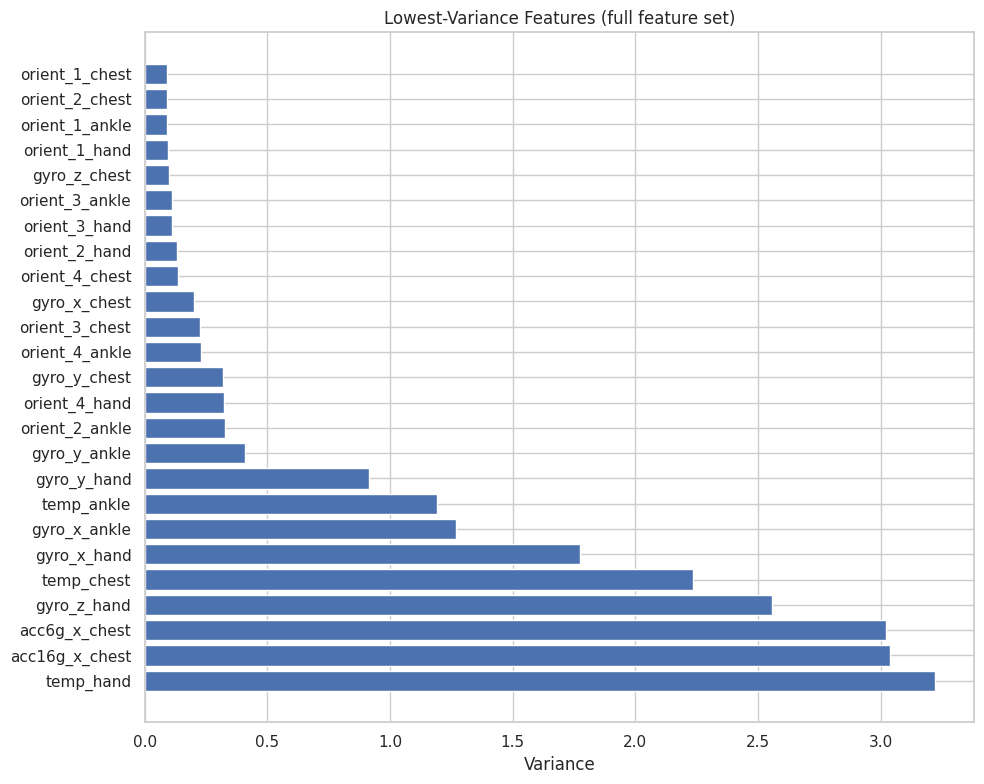

In [14]:
plt.figure(figsize=(10, 8))
plot_df = var_df.head(25).iloc[::-1]
plt.barh(plot_df.index, plot_df.values)
plt.title('Lowest-Variance Features (full feature set)')
plt.xlabel('Variance')
plt.tight_layout()
plt.show()


In [15]:
# Subject-wise feature shift: compare subject means for a chosen feature set
feature_set = 'full'  # change this to inspect another group
subject_means = []
for sid, df in preprocessed[feature_set].items():
    feat = df.drop(columns=['activity_id'])
    subject_means.append(pd.Series(feat.mean().values, index=feat.columns, name=sid))
subject_means = pd.DataFrame(subject_means)
subject_means.head()


,heart_rate,temp_hand,acc16g_x_hand,acc16g_y_hand,acc16g_z_hand,acc6g_x_hand,acc6g_y_hand,acc6g_z_hand,gyro_x_hand,gyro_y_hand,...,gyro_x_ankle,gyro_y_ankle,gyro_z_ankle,mag_x_ankle,mag_y_ankle,mag_z_ankle,orient_1_ankle,orient_2_ankle,orient_3_ankle,orient_4_ankle
1,122.191599,32.422762,-4.140228,5.843439,3.736326,-4.100919,5.876625,3.897167,0.058272,0.068614,...,0.003577,0.008968,0.015002,-49.519531,-3.850691,13.561252,1.000000,0.000000,0.000000,0.000000
2,109.492825,32.335509,-5.165098,4.827645,3.015019,-5.114576,4.852302,3.166203,0.049894,0.045829,...,-0.032105,-0.059540,-0.000485,-28.827144,1.240838,17.122231,0.278948,-0.010593,0.349072,-0.086884
3,95.105060,31.886316,-4.521142,4.378806,3.649820,-4.492908,4.395570,3.773161,0.000653,-0.023341,...,-0.006836,-0.035369,0.028121,-24.793782,3.956014,17.872399,0.234804,-0.041830,0.283870,-0.143664
4,109.433792,31.901968,-5.995209,3.384448,4.264892,-5.944091,3.403367,4.417618,-0.024320,0.014295,...,0.019843,-0.052051,0.011716,-27.818907,-2.984188,15.669378,0.290576,-0.139319,0.300636,-0.161722
5,108.526604,34.769571,-4.302963,5.539761,3.613392,-4.161100,5.556799,3.861057,0.010293,0.037899,...,0.006621,-0.040835,0.024440,-31.995869,2.610375,19.965522,0.293425,0.009719,0.418879,-0.017438


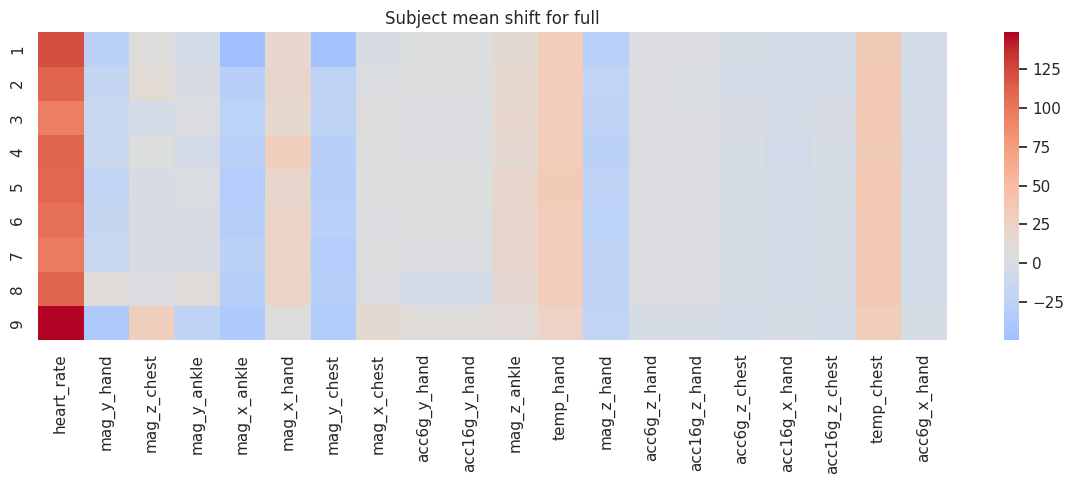

In [16]:
# Heatmap of subject means (subset of most variable mean features)
mean_var = subject_means.var(axis=0).sort_values(ascending=False)
show_cols = mean_var.head(20).index
plot_df = subject_means[show_cols]
plt.figure(figsize=(12, 5))
if sns is not None:
    sns.heatmap(plot_df, cmap='coolwarm', center=plot_df.values.mean())
else:
    plt.imshow(plot_df, aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.xticks(range(len(show_cols)), show_cols, rotation=90)
    plt.yticks(range(len(plot_df.index)), plot_df.index)
plt.title(f'Subject mean shift for {feature_set}')
plt.tight_layout()
plt.show()


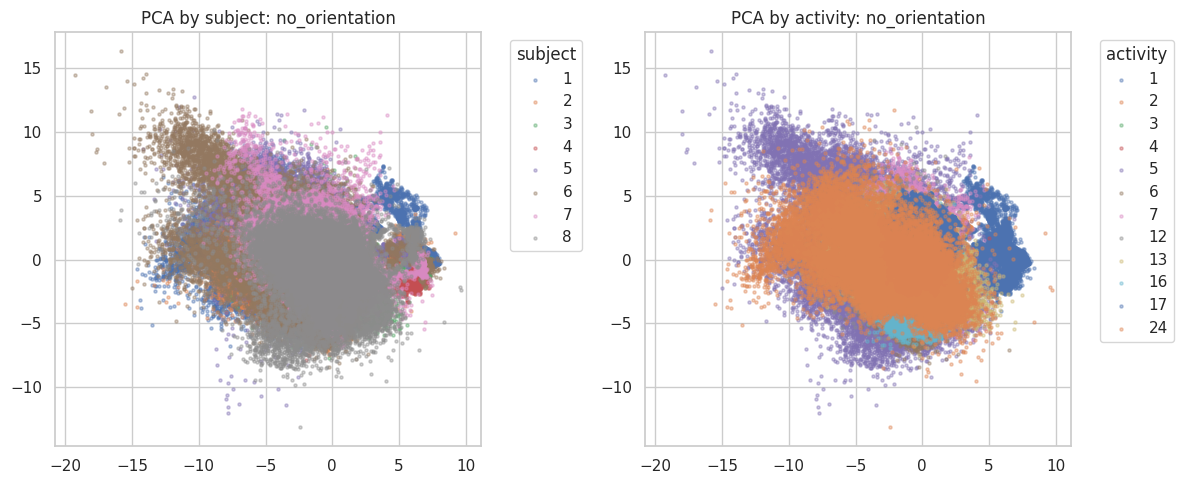

: 

In [ ]:
# PCA to inspect whether features separate subject more than activity
feature_set = 'no_orientation'
plot_sid = [1, 2, 3, 4, 5, 6, 7, 8]
plot_df = pd.concat([
    preprocessed[feature_set][sid].assign(subject=sid)
    for sid in plot_sid
], ignore_index=True)

X = plot_df.drop(columns=['activity_id', 'subject']).values
pca = PCA(n_components=2)
X2 = pca.fit_transform(StandardScaler().fit_transform(X))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for sid in sorted(plot_df['subject'].unique()):
    mask = plot_df['subject'] == sid
    axes[0].scatter(X2[mask, 0], X2[mask, 1], s=5, alpha=0.4, label=str(sid))
axes[0].set_title(f'PCA by subject: {feature_set}')
axes[0].legend(title='subject', bbox_to_anchor=(1.05, 1), loc='upper left')

for act in sorted(plot_df['activity_id'].unique())[:12]:
    mask = plot_df['activity_id'] == act
    axes[1].scatter(X2[mask, 0], X2[mask, 1], s=5, alpha=0.4, label=str(act))
axes[1].set_title(f'PCA by activity: {feature_set}')
axes[1].legend(title='activity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# Fast feature-group comparison with a simple linear baseline.
# This is not your FuseMoE model; it is only for deciding which feature groups look useful.
TRAIN_SUBJECTS = [3, 4, 5, 6, 7, 8, 9]
VAL_SUBJECTS = [2]
TEST_SUBJECTS = [1]

results = []
for feature_set, subject_map in preprocessed.items():
    train_df = pd.concat([subject_map[sid] for sid in TRAIN_SUBJECTS], ignore_index=True)
    val_df = pd.concat([subject_map[sid] for sid in VAL_SUBJECTS], ignore_index=True)
    test_df = pd.concat([subject_map[sid] for sid in TEST_SUBJECTS], ignore_index=True)

    X_train = train_df.drop(columns=['activity_id']).values
    y_train = train_df['activity_id'].values
    X_val = val_df.drop(columns=['activity_id']).values
    y_val = val_df['activity_id'].values
    X_test = test_df.drop(columns=['activity_id']).values
    y_test = test_df['activity_id'].values

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=300, multi_class='multinomial')
    )
    clf.fit(X_train, y_train)
    val_pred = clf.predict(X_val)
    test_pred = clf.predict(X_test)

    results.append({
        'feature_set': feature_set,
        'n_features': X_train.shape[1],
        'val_acc': accuracy_score(y_val, val_pred),
        'val_macro_f1': f1_score(y_val, val_pred, average='macro'),
        'test_acc': accuracy_score(y_test, test_pred),
        'test_macro_f1': f1_score(y_test, test_pred, average='macro'),
    })

baseline_results = pd.DataFrame(results).sort_values('test_macro_f1', ascending=False)
baseline_results


## How to use the notebook output

Useful interpretation rules:
- If a feature group has a much smaller val-test gap, it may generalize better even if its raw val score is a little lower.
- If PCA separates subjects more clearly than activities, those features may be carrying subject-specific bias.
- If `no_orientation` or `no_orientation_no_temp` performs similarly or better than `full`, those channels are good removal candidates.
- If subject 9 remains a clear outlier in raw coverage and class support, consider treating it as a special-case analysis rather than part of the main benchmark.
